In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


In [5]:
df_dft = pd.read_parquet("../../data/processed/fitting/anisotropy_weight_scan_dft.parquet")
df_free = pd.read_parquet("../../data/processed/fitting/anisotropy_weight_scan.parquet")
#  Drop "Unnamed: 0" column if it exists and obj
df_dft = df_dft.loc[:, ~df_dft.columns.str.contains("^Unnamed")]
df_free = df_free.loc[:, ~df_free.columns.str.contains("^Unnamed")]
df_dft = df_dft.loc[:, ~df_dft.columns.str.contains("obj")]
df_free = df_free.loc[:, ~df_free.columns.str.contains("obj")]

In [6]:
# Validate each of the de_history arrays to make sure that they are the same lenght.
# 1. Find the maximum length
# 2. Pad the shorter arrays at the end with the last value - since the arrays converged,
#  the last value is the same as the previous one

def pad_de_history(de_history, desired_length=100):
    """
    Pad a numpy array to the desired length by repeating the last value.
    If the original array is already at least the desired length, return as is.
    If there is just a single value, do nothing (return as is).
    """
    if len(de_history.shape) == 0 or de_history.size == 1:
        return de_history
    if len(de_history) < desired_length:
        return np.pad(
            de_history,
            (0, desired_length - len(de_history)),
            mode='constant',
            constant_values=de_history[-1] if len(de_history) > 0 else 0
        )
    return de_history

df_dft["de_history_padded"] = df_dft["de_history"].apply(lambda x: pad_de_history(x))
df_free["de_history_padded"] = df_free["de_history"].apply(lambda x: pad_de_history(x))


In [64]:
# normalize the de_history to place the median final value at 0. If the final value
# at 0. If the fit did not converge, do not include it in the normalization. If the
# if there is only one value, do not include it in the normalization.

def normalize_de_history(df):
    final_values = []
    for _, row in df.iterrows():
        de_history = row["de_history_padded"]
        if len(de_history) == 1:
            final_values.append(0)
        else:
            final_values.append(de_history[-1])
    median_final_value = np.median(final_values)
    df["de_history_normalized"] = (
        df["de_history_padded"]
            .apply(lambda x: x - median_final_value)
        )
    return df

df_dft = normalize_de_history(df_dft)
df_free = normalize_de_history(df_free)


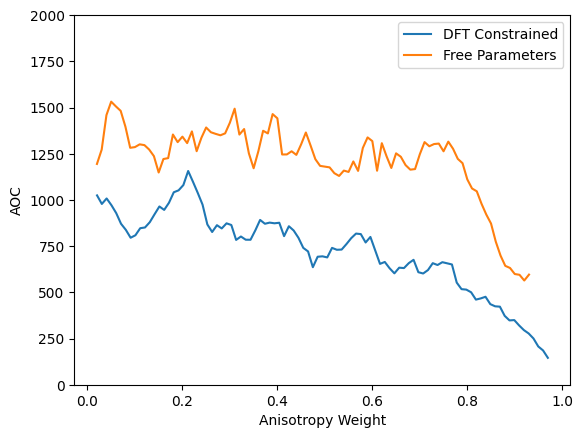

In [7]:
def auc(de_history):
    if len(de_history) == 1:
        return np.nan
    return np.trapezoid(de_history, dx=1)

#  compute the AOC of the de_history for each row of the dataframe
df_dft["aoc"] = df_dft["de_history"].apply(lambda x: auc(x))
df_free["aoc"] = df_free["de_history"].apply(lambda x: auc(x))

# Do a box cart smoothing of the AOC
df_dft["aoc_smoothed"] = df_dft["aoc"].rolling(window=5, center=True).mean()
df_free["aoc_smoothed"] = df_free["aoc"].rolling(window=5, center=True).mean()

# Plot the AOC of the de_history for each row of the dataframe
ax = df_dft.plot(x="weight", y="aoc_smoothed", label="DFT Constrained")
df_free.plot(x="weight", y="aoc_smoothed", label="Free Parameters", ax=ax)
ax.set_xlabel("Anisotropy Weight")
ax.set_ylabel("AOC")
ax.set_ylim(0, 2000)
ax.legend()
plt.show()


/tmp/ipykernel_3812226/2007336384.py:176: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


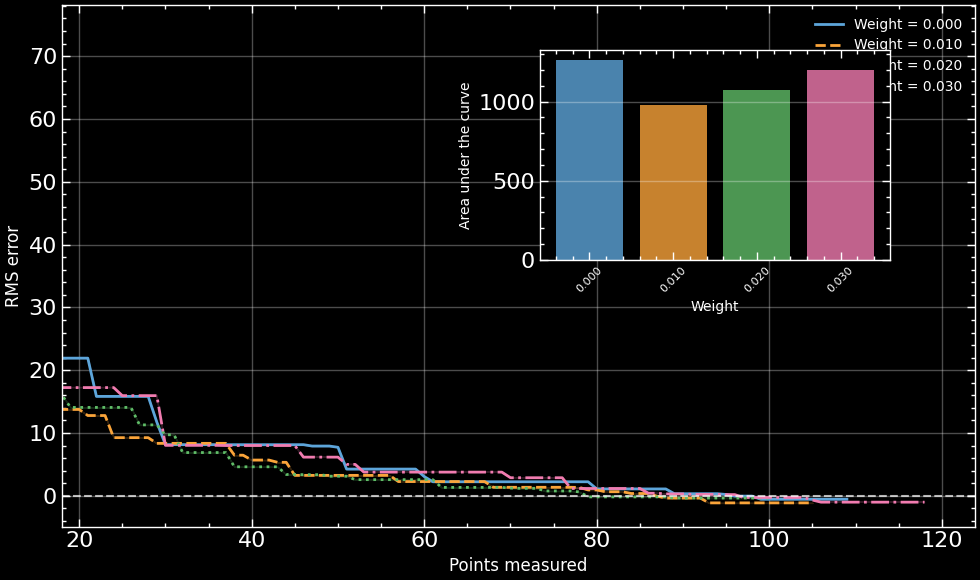

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scienceplots

plt.style.use(["science", "notebook"])

def pad_de_history(de_history: np.ndarray, desired_length: int = 100) -> np.ndarray:
    if len(de_history.shape) == 0 or de_history.size == 1:
        return de_history
    if len(de_history) < desired_length:
        return np.pad(
            de_history,
            (0, desired_length - len(de_history)),
            mode="constant",
            constant_values=de_history[-1] if len(de_history) > 0 else 0,
        )
    return de_history

def normalize_de_history(df: pd.DataFrame) -> pd.DataFrame:
    final_values = []
    for _, row in df.iterrows():
        de_history = row["de_history_padded"]
        if len(de_history) == 1:
            final_values.append(0)
        else:
            final_values.append(de_history[-1])
    median_final_value = np.median(final_values)
    df["de_history_normalized"] = df["de_history_padded"].apply(
        lambda x: x - median_final_value
    )
    return df

def auc(de_history: np.ndarray) -> float:
    if len(de_history) == 1:
        return np.nan
    return np.trapezoid(de_history, dx=1)

df_dft = pd.read_parquet("../../data/processed/fitting/anisotropy_weight_scan_dft.parquet")
df_free = pd.read_parquet("../../data/processed/fitting/anisotropy_weight_scan.parquet")

df_dft = df_dft.loc[:, ~df_dft.columns.str.contains("^Unnamed")]
df_free = df_free.loc[:, ~df_free.columns.str.contains("^Unnamed")]
df_dft = df_dft.loc[:, ~df_dft.columns.str.contains("obj")]
df_free = df_free.loc[:, ~df_free.columns.str.contains("obj")]

df_dft["de_history_padded"] = df_dft["de_history"].apply(
    lambda x: pad_de_history(x, desired_length=100)
)
df_free["de_history_padded"] = df_free["de_history"].apply(
    lambda x: pad_de_history(x, desired_length=100)
)

df_dft = normalize_de_history(df_dft)
df_free = normalize_de_history(df_free)

df_dft["aoc"] = df_dft["de_history"].apply(auc)
df_free["aoc"] = df_free["de_history"].apply(auc)

df = df_free

weights = sorted(df["weight"].unique())
if "de_history_normalized" in df.columns:
    max_length = max(len(hist) for hist in df["de_history_normalized"])
else:
    max_length = max(len(hist) for hist in df["de_history_padded"])

convergence_data = {}
aoc_data = {}

for weight in weights:
    weight_df = df[df["weight"] == weight]

    histories = []
    for _, row in weight_df.iterrows():
        hist = row.get("de_history_normalized", row["de_history_padded"])
        if len(hist) > 1:
            histories.append(hist)

    if not histories:
        continue

    max_hist_len = max(len(h) for h in histories)
    padded_histories = [
        pad_de_history(np.array(h), desired_length=max_hist_len) for h in histories
    ]

    histories_array = np.array(padded_histories)
    mean_history = np.mean(histories_array, axis=0)
    std_history = np.std(histories_array, axis=0)

    convergence_data[weight] = {
        "mean": mean_history,
        "std": std_history,
        "points": np.arange(1, len(mean_history) + 1),
    }

    aoc_values = weight_df["aoc"].dropna()
    if len(aoc_values) > 0:
        aoc_data[weight] = {
            "mean": aoc_values.mean(),
            "std": aoc_values.std(),
        }

fig, ax = plt.subplots(figsize=(10, 6))

line_styles = ["-", "--", ":", "-."]
colors = ["#5DA5DA", "#FAA43A", "#60BD68", "#F17CB0"]

selected_weights = sorted(weights)[:4] if len(weights) >= 4 else sorted(weights)

for idx, weight in enumerate(selected_weights):
    if weight not in convergence_data:
        continue

    data = convergence_data[weight]
    style = line_styles[idx % len(line_styles)]
    color = colors[idx % len(colors)]

    ax.plot(
        data["points"],
        data["mean"],
        linestyle=style,
        color=color,
        linewidth=2,
        label=f"Weight = {weight:.3f}",
    )

    ax.fill_between(
        data["points"],
        data["mean"] - data["std"],
        data["mean"] + data["std"],
        alpha=0.2,
        color=color,
    )

threshold = 0.005
ax.axhline(y=threshold, color="white", linestyle="--", linewidth=1.5, alpha=0.7)

ax.set_xlabel("Points measured", fontsize=12)
ax.set_ylabel("RMS error", fontsize=12)
ax.set_xlim(left=18)
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right", fontsize=10)

ax_inset = fig.add_axes([0.55, 0.55, 0.35, 0.35])

aoc_means = []
aoc_stds = []
aoc_weights = []

for weight in selected_weights:
    if weight in aoc_data:
        aoc_means.append(aoc_data[weight]["mean"])
        aoc_stds.append(aoc_data[weight]["std"])
        aoc_weights.append(weight)

x_pos = np.arange(len(aoc_means))
bars = ax_inset.bar(
    x_pos,
    aoc_means,
    yerr=aoc_stds,
    color=colors[: len(aoc_means)],
    alpha=0.8,
    capsize=5,
    error_kw={"elinewidth": 1.5},
)

ax_inset.set_ylabel("Area under the curve", fontsize=10)
ax_inset.set_xticks(x_pos)
ax_inset.set_xticklabels([f"{w:.3f}" for w in aoc_weights], fontsize=8, rotation=45)
ax_inset.set_xlabel("Weight", fontsize=10)
ax_inset.grid(True, alpha=0.3, axis="y")
ax_inset.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig("convergence_aoc_plot.png", dpi=300, bbox_inches="tight")
plt.show()

0.0
0.25
0.49
0.5
Closest weights to 0.5: [np.float64(0.49), np.float64(0.51), np.float64(0.48), np.float64(0.52), np.float64(0.47)]
1.0
Closest weights to 1.0: [np.float64(0.95), np.float64(0.94), np.float64(0.93), np.float64(0.92), np.float64(0.91)]


/tmp/ipykernel_3827799/704636670.py:254: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


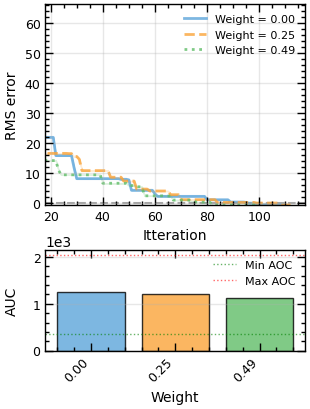

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scienceplots

plt.style.use(["science", "notebook"])

def pad_de_history(de_history: np.ndarray, desired_length: int = 100) -> np.ndarray:
    if len(de_history.shape) == 0 or de_history.size == 1:
        return de_history
    if len(de_history) < desired_length:
        return np.pad(
            de_history,
            (0, desired_length - len(de_history)),
            mode="constant",
            constant_values=de_history[-1] if len(de_history) > 0 else 0,
        )
    return de_history

def normalize_de_history(df: pd.DataFrame) -> pd.DataFrame:
    final_values = []
    for _, row in df.iterrows():
        de_history = row["de_history_padded"]
        if len(de_history) == 1:
            final_values.append(0)
        else:
            final_values.append(de_history[-1])
    median_final_value = np.median(final_values)
    df["de_history_normalized"] = df["de_history_padded"].apply(
        lambda x: x - median_final_value
    )
    return df

def auc(de_history: np.ndarray) -> float:
    if len(de_history) == 1:
        return np.nan
    return np.trapezoid(de_history, dx=1)

df_dft = pd.read_parquet("../../data/processed/fitting/anisotropy_weight_scan_dft.parquet")
df_free = pd.read_parquet("../../data/processed/fitting/anisotropy_weight_scan.parquet")

df_dft = df_dft.loc[:, ~df_dft.columns.str.contains("^Unnamed")]
df_free = df_free.loc[:, ~df_free.columns.str.contains("^Unnamed")]
df_dft = df_dft.loc[:, ~df_dft.columns.str.contains("obj")]
df_free = df_free.loc[:, ~df_free.columns.str.contains("obj")]

df_dft["de_history_padded"] = df_dft["de_history"].apply(
    lambda x: pad_de_history(x, desired_length=100)
)
df_free["de_history_padded"] = df_free["de_history"].apply(
    lambda x: pad_de_history(x, desired_length=100)
)

df_dft = normalize_de_history(df_dft)
df_free = normalize_de_history(df_free)

df_dft["aoc"] = df_dft["de_history"].apply(auc)
df_free["aoc"] = df_free["de_history"].apply(auc)

df = df_free

weights = sorted(df["weight"].unique())
weights_0_to_1 = [w for w in weights if 0 <= w <= 1]

if "de_history_normalized" in df.columns:
    max_length = max(len(hist) for hist in df["de_history_normalized"])
else:
    max_length = max(len(hist) for hist in df["de_history_padded"])

convergence_data = {}
aoc_data = {}

for weight in weights_0_to_1:
    weight_df = df[df["weight"] == weight]

    histories = []
    for _, row in weight_df.iterrows():
        hist = row.get("de_history_normalized", row["de_history_padded"])
        if len(hist) > 1:
            histories.append(hist)

    if not histories:
        continue

    max_hist_len = max(len(h) for h in histories)
    padded_histories = [
        pad_de_history(np.array(h), desired_length=max_hist_len) for h in histories
    ]

    histories_array = np.array(padded_histories)
    mean_history = np.mean(histories_array, axis=0)
    std_history = np.std(histories_array, axis=0)

    convergence_data[weight] = {
        "mean": mean_history,
        "std": std_history,
        "points": np.arange(1, len(mean_history) + 1),
    }

    aoc_values = weight_df["aoc"].dropna()
    if len(aoc_values) > 0:
        aoc_data[weight] = {
            "mean": aoc_values.mean(),
            "std": aoc_values.std(),
        }

aoc_means_all = [aoc_data[w]["mean"] for w in aoc_data.keys()]
min_aoc = min(aoc_means_all)
max_aoc = max(aoc_means_all)
# Determine the weights associated with the min and max AUC
min_aoc_weight = min(aoc_data, key=lambda x: aoc_data[x]["mean"])
max_aoc_weight = max(aoc_data, key=lambda x: aoc_data[x]["mean"])
weights_0_to_1.append(min_aoc_weight)
weights_0_to_1.append(max_aoc_weight)
# Add 0.5 if it is not in the list
if 0.5 not in weights_0_to_1:
    weights_0_to_1.append(0.5)
    weights_0_to_1 = sorted(weights_0_to_1)


selected_weights = sorted(weights_0_to_1)

if len(selected_weights) > 4:
    step = len(selected_weights) // 4
    selected_weights = [selected_weights[i] for i in range(0, len(selected_weights), step)][:4]
    if selected_weights[-1] != 1.0:
        selected_weights[-1] = 1.0
    if 0.5 not in selected_weights:
        selected_weights.append(0.5)
        selected_weights = sorted(selected_weights)

if 0.5 not in selected_weights and 0.5 in weights_0_to_1:
    selected_weights.append(0.5)
    selected_weights = sorted(selected_weights)

fig_width = 3.35
fig_height = 4.5
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(fig_width, fig_height),
    height_ratios=[2, 1],
    gridspec_kw={"hspace": 0.3})

line_styles = ["-", "--", ":", "-."]
colors = ["#5DA5DA", "#FAA43A", "#60BD68", "#F17CB0", "#B276B2", "#DECF3F"]

for idx, weight in enumerate(selected_weights):
    print(weight)
    if weight not in convergence_data:
        # Print the closest weights in convergence_data
        closest_weights = sorted(convergence_data.keys(), key=lambda x: abs(x - weight))
        print(f"Closest weights to {weight}: {closest_weights[:5]}")
        continue

    data = convergence_data[weight]
    style = line_styles[idx % len(line_styles)]
    color = colors[idx % len(colors)]

    is_chosen = abs(weight - 0.5) < 1e-6

    linewidth = 3.0 if is_chosen else 2.0
    alpha = 1.0 if is_chosen else 0.8
    zorder = 10 if is_chosen else 1

    ax1.plot(
        data["points"],
        data["mean"],
        linestyle=style,
        color=color,
        linewidth=linewidth,
        label=f"Weight = {weight:.1f}" if weight == 0.5 else f"Weight = {weight:.2f}",
        alpha=alpha,
        zorder=zorder,
    )

    if not is_chosen:
        ax1.fill_between(
            data["points"],
            data["mean"] - data["std"],
            data["mean"] + data["std"],
            alpha=0.2,
            color=color,
        )

threshold = 0.005
ax1.axhline(y=threshold, color="gray", linestyle="--", linewidth=1.5, alpha=0.7, zorder=0)

all_means = []
for weight in selected_weights:
    if weight in convergence_data:
        all_means.extend(convergence_data[weight]["mean"])

y_min = min(all_means) - 0.01
y_max = max(all_means) + 0.01
ax1.set_ylim(y_min, y_max)

ax1.set_xlabel("Itteration", fontsize=10)
ax1.set_ylabel("RMS error", fontsize=10)
ax1.set_xlim(left=18)
ax1.tick_params(axis="both", labelsize=9)
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper right", fontsize=8, framealpha=0.9)

aoc_means = []
aoc_stds = []
aoc_weights = []
aoc_colors = []

for weight in selected_weights:
    if weight in aoc_data:
        aoc_means.append(aoc_data[weight]["mean"])
        aoc_stds.append(aoc_data[weight]["std"])
        aoc_weights.append(weight)
        is_chosen = abs(weight - 0.5) < 1e-6
        if is_chosen:
            aoc_colors.append("#E74C3C")
        else:
            color_idx = selected_weights.index(weight) % len(colors)
            aoc_colors.append(colors[color_idx])

x_pos = np.arange(len(aoc_means))
edgecolors = ["#E74C3C" if abs(w - 0.5) < 1e-6 else "none" for w in aoc_weights]
edgewidths = [3 if abs(w - 0.5) < 1e-6 else 1 for w in aoc_weights]

bars = ax2.bar(
    x_pos,
    aoc_means,
    yerr=aoc_stds,
    color=aoc_colors,
    alpha=0.8,
    capsize=5,
    edgecolor=edgecolors,
    linewidth=edgewidths,
    error_kw={"elinewidth": 1.5},
)

ax2.axhline(y=min_aoc, color="green", linestyle=":", linewidth=1, alpha=0.6, label="Min AOC")
ax2.axhline(y=max_aoc, color="red", linestyle=":", linewidth=1, alpha=0.6, label="Max AOC")

ax2.set_ylabel("AUC", fontsize=10)
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f"{w:.1f}" if w == 0.5 else f"{w:.2f}" for w in aoc_weights], fontsize=9, rotation=45, ha="right")
ax2.set_xlabel("Weight", fontsize=10)
ax2.tick_params(axis="both", labelsize=9)
ax2.grid(True, alpha=0.3, axis="y")
ax2.set_ylim(bottom=0)
ax2.legend(fontsize=8, loc="upper right", framealpha=0.9)
# force scientific notation for y-axis
ax2.ticklabel_format(style="sci", axis="y", scilimits=(0,0))
ax2.yaxis.get_offset_text().set_fontsize(10)

fig.align_ylabels([ax1, ax2])

plt.tight_layout()
plt.savefig("convergence_aoc_plot.png", dpi=300, bbox_inches="tight")
plt.show()

Selected weights: [0.0, np.float64(0.36), np.float64(0.89), 1.0]
Min AUC weight: 0.360, Max AUC weight: 0.890
Weight 1.0 not in convergence_data. Closest: [np.float64(0.95), np.float64(0.94), np.float64(0.93), np.float64(0.92), np.float64(0.91)]


/tmp/ipykernel_3827799/2107126419.py:272: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


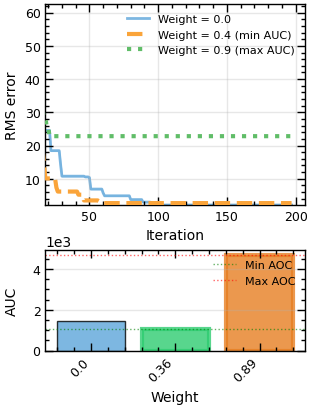

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scienceplots

plt.style.use(["science", "notebook"])

def pad_de_history(de_history: np.ndarray, desired_length: int = 100) -> np.ndarray:
    if len(de_history.shape) == 0 or de_history.size == 1:
        return de_history
    if len(de_history) < desired_length:
        return np.pad(
            de_history,
            (0, desired_length - len(de_history)),
            mode="constant",
            constant_values=de_history[-1] if len(de_history) > 0 else 0,
        )
    return de_history

def normalize_de_history(df: pd.DataFrame) -> pd.DataFrame:
    final_values = []
    for _, row in df.iterrows():
        de_history = row["de_history_padded"]
        if len(de_history) == 1:
            final_values.append(0)
        else:
            final_values.append(de_history[-1])
    min_final_value = np.min(final_values)
    df["de_history_normalized"] = df["de_history_padded"].apply(
        lambda x: x - min_final_value
    )
    return df

def auc(de_history: np.ndarray) -> float:
    if len(de_history) == 1:
        return np.nan
    return np.trapezoid(de_history, dx=1)

df_dft = pd.read_parquet("../../data/processed/fitting/anisotropy_weight_scan_dft.parquet")
df_free = pd.read_parquet("../../data/processed/fitting/anisotropy_weight_scan.parquet")

df_dft = df_dft.loc[:, ~df_dft.columns.str.contains("^Unnamed")]
df_free = df_free.loc[:, ~df_free.columns.str.contains("^Unnamed")]
df_dft = df_dft.loc[:, ~df_dft.columns.str.contains("obj")]
df_free = df_free.loc[:, ~df_free.columns.str.contains("obj")]

max_length = max(
    max(len(hist) for hist in df_dft["de_history"] if len(hist) > 1),
    max(len(hist) for hist in df_free["de_history"] if len(hist) > 1),
)

df_dft["de_history_padded"] = df_dft["de_history"].apply(
    lambda x: pad_de_history(x, desired_length=max_length)
)
df_free["de_history_padded"] = df_free["de_history"].apply(
    lambda x: pad_de_history(x, desired_length=max_length)
)

df_dft = normalize_de_history(df_dft)
df_free = normalize_de_history(df_free)

df_dft["aoc"] = df_dft["de_history_padded"].apply(auc)
df_free["aoc"] = df_free["de_history_padded"].apply(auc)

df = df_free

weights = sorted(df["weight"].unique())
weights_0_to_1 = [w for w in weights if 0 <= w <= 1]

convergence_data = {}
aoc_data = {}

for weight in weights_0_to_1:
    weight_df = df[df["weight"] == weight]

    histories = []
    for _, row in weight_df.iterrows():
        hist = row.get("de_history_normalized", row["de_history_padded"])
        if len(hist) > 1:
            histories.append(hist)

    if not histories:
        continue

    max_hist_len = max(len(h) for h in histories)
    padded_histories = [
        pad_de_history(np.array(h), desired_length=max_hist_len) for h in histories
    ]

    histories_array = np.array(padded_histories)
    mean_history = np.mean(histories_array, axis=0)
    std_history = np.std(histories_array, axis=0)

    convergence_data[weight] = {
        "mean": mean_history,
        "std": std_history,
        "points": np.arange(1, len(mean_history) + 1),
    }

    aoc_values = weight_df["aoc"].dropna()
    if len(aoc_values) > 0:
        aoc_data[weight] = {
            "mean": aoc_values.mean(),
            "std": aoc_values.std(),
        }

aoc_means_all = [aoc_data[w]["mean"] for w in aoc_data.keys()]
min_aoc = min(aoc_means_all)
max_aoc = max(aoc_means_all)
min_aoc_weight = min(aoc_data, key=lambda x: aoc_data[x]["mean"])
max_aoc_weight = max(aoc_data, key=lambda x: aoc_data[x]["mean"])

selected_weights = []
for weight in [0.0, 0.5, 1.0, min_aoc_weight, max_aoc_weight]:
    if weight in weights_0_to_1:
        selected_weights.append(weight)

selected_weights = sorted(list(set(selected_weights)))

print(f"Selected weights: {selected_weights}")
print(f"Min AUC weight: {min_aoc_weight:.3f}, Max AUC weight: {max_aoc_weight:.3f}")

fig_width = 3.35
fig_height = 4.5
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(fig_width, fig_height),
    height_ratios=[2, 1],
    gridspec_kw={"hspace": 0.3}
)

line_styles = ["-", "--", ":", "-.", "-"]
colors = ["#5DA5DA", "#FAA43A", "#60BD68", "#F17CB0", "#B276B2", "#DECF3F"]

for idx, weight in enumerate(selected_weights):
    if weight not in convergence_data:
        closest_weights = sorted(convergence_data.keys(), key=lambda x: abs(x - weight))
        print(f"Weight {weight} not in convergence_data. Closest: {closest_weights[:5]}")
        continue

    data = convergence_data[weight]
    style = line_styles[idx % len(line_styles)]
    color = colors[idx % len(colors)]

    is_chosen = abs(weight - 0.5) < 1e-6
    is_min = abs(weight - min_aoc_weight) < 1e-6
    is_max = abs(weight - max_aoc_weight) < 1e-6

    linewidth = 3.0 if (is_chosen or is_min or is_max) else 2.0
    alpha = 1.0 if (is_chosen or is_min or is_max) else 0.8
    zorder = 10 if (is_chosen or is_min or is_max) else 1

    label = f"Weight = {weight:.1f}"
    if is_chosen:
        label += " (chosen)"
    elif is_min:
        label += " (min AUC)"
    elif is_max:
        label += " (max AUC)"

    ax1.plot(
        data["points"],
        data["mean"],
        linestyle=style,
        color=color,
        linewidth=linewidth,
        label=label,
        alpha=alpha,
        zorder=zorder,
    )

    if not (is_chosen or is_min or is_max):
        ax1.fill_between(
            data["points"],
            data["mean"] - data["std"],
            data["mean"] + data["std"],
            alpha=0.2,
            color=color,
        )

threshold = 0.005
ax1.axhline(y=threshold, color="gray", linestyle="--", linewidth=1.5, alpha=0.7, zorder=0)

all_means = []
for weight in selected_weights:
    if weight in convergence_data:
        all_means.extend(convergence_data[weight]["mean"])

y_min = min(all_means) - 0.01
y_max = max(all_means) + 0.01
ax1.set_ylim(y_min, y_max)

ax1.set_xlabel("Iteration", fontsize=10)
ax1.set_ylabel("RMS error", fontsize=10)
ax1.set_xlim(left=18)
ax1.tick_params(axis="both", labelsize=9)
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper right", fontsize=8, framealpha=0.9)

aoc_means = []
aoc_stds = []
aoc_weights = []
aoc_colors = []

for weight in selected_weights:
    if weight in aoc_data:
        aoc_means.append(aoc_data[weight]["mean"])
        aoc_stds.append(aoc_data[weight]["std"])
        aoc_weights.append(weight)
        is_chosen = abs(weight - 0.5) < 1e-6
        is_min = abs(weight - min_aoc_weight) < 1e-6
        is_max = abs(weight - max_aoc_weight) < 1e-6

        if is_chosen:
            aoc_colors.append("#E74C3C")
        elif is_min:
            aoc_colors.append("#2ECC71")
        elif is_max:
            aoc_colors.append("#E67E22")
        else:
            color_idx = selected_weights.index(weight) % len(colors)
            aoc_colors.append(colors[color_idx])

x_pos = np.arange(len(aoc_means))
edgecolors = []
edgewidths = []
for w in aoc_weights:
    is_chosen = abs(w - 0.5) < 1e-6
    is_min = abs(w - min_aoc_weight) < 1e-6
    is_max = abs(w - max_aoc_weight) < 1e-6
    if is_chosen:
        edgecolors.append("#E74C3C")
        edgewidths.append(3)
    elif is_min:
        edgecolors.append("#2ECC71")
        edgewidths.append(3)
    elif is_max:
        edgecolors.append("#E67E22")
        edgewidths.append(3)
    else:
        edgecolors.append("none")
        edgewidths.append(1)

bars = ax2.bar(
    x_pos,
    aoc_means,
    yerr=aoc_stds,
    color=aoc_colors,
    alpha=0.8,
    capsize=5,
    edgecolor=edgecolors,
    linewidth=edgewidths,
    error_kw={"elinewidth": 1.5},
)

ax2.axhline(y=min_aoc, color="green", linestyle=":", linewidth=1, alpha=0.6, label="Min AOC")
ax2.axhline(y=max_aoc, color="red", linestyle=":", linewidth=1, alpha=0.6, label="Max AOC")

ax2.set_ylabel("AUC", fontsize=10)
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f"{w:.1f}" if w in [0.0, 0.5, 1.0] else f"{w:.2f}" for w in aoc_weights], fontsize=9, rotation=45, ha="right")
ax2.set_xlabel("Weight", fontsize=10)
ax2.tick_params(axis="both", labelsize=9)
ax2.grid(True, alpha=0.3, axis="y")
ax2.set_ylim(bottom=0)
ax2.legend(fontsize=8, loc="upper right", framealpha=0.9)
ax2.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
ax2.yaxis.get_offset_text().set_fontsize(10)

fig.align_ylabels([ax1, ax2])

plt.tight_layout()
plt.savefig("convergence_aoc_plot.png", dpi=300, bbox_inches="tight")
plt.show()

Selected weights: [0.0, np.float64(0.36), np.float64(0.89)]
Min AUC weight: 0.360, Max AUC weight: 0.890


/tmp/ipykernel_3827799/1209850907.py:266: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


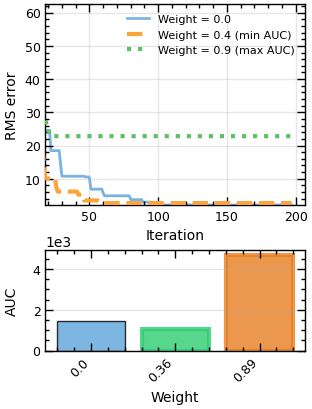

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scienceplots

plt.style.use(["science", "notebook"])

def pad_de_history(de_history: np.ndarray, desired_length: int = 100) -> np.ndarray:
    if len(de_history.shape) == 0 or de_history.size == 1:
        return de_history
    if len(de_history) < desired_length:
        return np.pad(
            de_history,
            (0, desired_length - len(de_history)),
            mode="constant",
            constant_values=de_history[-1] if len(de_history) > 0 else 0,
        )
    return de_history

def normalize_de_history(df: pd.DataFrame) -> pd.DataFrame:
    final_values = []
    for _, row in df.iterrows():
        de_history = row["de_history_padded"]
        if len(de_history) == 1:
            final_values.append(0)
        else:
            final_values.append(de_history[-1])
    min_final_value = np.min(final_values)
    df["de_history_normalized"] = df["de_history_padded"].apply(
        lambda x: x - min_final_value
    )
    return df

def auc(de_history: np.ndarray) -> float:
    if len(de_history) == 1:
        return np.nan
    return np.trapezoid(de_history, dx=1)

df_dft = pd.read_parquet("../../data/processed/fitting/anisotropy_weight_scan_dft.parquet")
df_free = pd.read_parquet("../../data/processed/fitting/anisotropy_weight_scan.parquet")

df_dft = df_dft.loc[:, ~df_dft.columns.str.contains("^Unnamed")]
df_free = df_free.loc[:, ~df_free.columns.str.contains("^Unnamed")]
df_dft = df_dft.loc[:, ~df_dft.columns.str.contains("obj")]
df_free = df_free.loc[:, ~df_free.columns.str.contains("obj")]

max_length = max(
    max(len(hist) for hist in df_dft["de_history"] if len(hist) > 1),
    max(len(hist) for hist in df_free["de_history"] if len(hist) > 1),
)

df_dft["de_history_padded"] = df_dft["de_history"].apply(
    lambda x: pad_de_history(x, desired_length=max_length)
)
df_free["de_history_padded"] = df_free["de_history"].apply(
    lambda x: pad_de_history(x, desired_length=max_length)
)

df_dft = normalize_de_history(df_dft)
df_free = normalize_de_history(df_free)

df_dft["aoc"] = df_dft["de_history_padded"].apply(auc)
df_free["aoc"] = df_free["de_history_padded"].apply(auc)

df = df_free

weights = sorted(df["weight"].unique())
weights_0_to_1 = [w for w in weights if 0 <= w <= 1]

convergence_data = {}
aoc_data = {}

for weight in weights_0_to_1:
    weight_df = df[df["weight"] == weight]

    histories = []
    for _, row in weight_df.iterrows():
        hist = row.get("de_history_normalized", row["de_history_padded"])
        if len(hist) > 1:
            histories.append(hist)

    if not histories:
        continue

    max_hist_len = max(len(h) for h in histories)
    padded_histories = [
        pad_de_history(np.array(h), desired_length=max_hist_len) for h in histories
    ]

    histories_array = np.array(padded_histories)
    mean_history = np.mean(histories_array, axis=0)
    std_history = np.std(histories_array, axis=0)

    convergence_data[weight] = {
        "mean": mean_history,
        "std": std_history,
        "points": np.arange(1, len(mean_history) + 1),
    }

    aoc_values = weight_df["aoc"].dropna()
    if len(aoc_values) > 0:
        aoc_data[weight] = {
            "mean": aoc_values.mean(),
            "std": aoc_values.std(),
        }

aoc_means_all = [aoc_data[w]["mean"] for w in aoc_data.keys()]
min_aoc = min(aoc_means_all)
max_aoc = max(aoc_means_all)
min_aoc_weight = min(aoc_data, key=lambda x: aoc_data[x]["mean"])
max_aoc_weight = max(aoc_data, key=lambda x: aoc_data[x]["mean"])

selected_weights = []
for weight in [0.0, 0.5, 1.0, min_aoc_weight, max_aoc_weight]:
    if weight in weights_0_to_1 and weight in convergence_data:
        selected_weights.append(weight)

selected_weights = sorted(list(set(selected_weights)))

print(f"Selected weights: {selected_weights}")
print(f"Min AUC weight: {min_aoc_weight:.3f}, Max AUC weight: {max_aoc_weight:.3f}")

fig_width = 3.35
fig_height = 4.5
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(fig_width, fig_height),
    height_ratios=[2, 1],
    gridspec_kw={"hspace": 0.3}
)

line_styles = ["-", "--", ":", "-.", "-"]
colors = ["#5DA5DA", "#FAA43A", "#60BD68", "#F17CB0", "#B276B2", "#DECF3F"]

for idx, weight in enumerate(selected_weights):
    if weight not in convergence_data:
        continue

    data = convergence_data[weight]
    style = line_styles[idx % len(line_styles)]
    color = colors[idx % len(colors)]

    is_chosen = abs(weight - 0.5) < 1e-6
    is_min = abs(weight - min_aoc_weight) < 1e-6
    is_max = abs(weight - max_aoc_weight) < 1e-6

    linewidth = 3.0 if (is_chosen or is_min or is_max) else 2.0
    alpha = 1.0 if (is_chosen or is_min or is_max) else 0.8
    zorder = 10 if (is_chosen or is_min or is_max) else 1

    label = f"Weight = {weight:.1f}"
    if is_chosen:
        label += " (chosen)"
    elif is_min:
        label += " (min AUC)"
    elif is_max:
        label += " (max AUC)"

    ax1.plot(
        data["points"],
        data["mean"],
        linestyle=style,
        color=color,
        linewidth=linewidth,
        label=label,
        alpha=alpha,
        zorder=zorder,
    )

    if not (is_chosen or is_min or is_max):
        ax1.fill_between(
            data["points"],
            data["mean"] - data["std"],
            data["mean"] + data["std"],
            alpha=0.2,
            color=color,
        )

threshold = 0.005
ax1.axhline(y=threshold, color="gray", linestyle="--", linewidth=1.5, alpha=0.7, zorder=0)

all_means = []
for weight in selected_weights:
    if weight in convergence_data:
        all_means.extend(convergence_data[weight]["mean"])

y_min = min(all_means) - 0.01
y_max = max(all_means) + 0.01
ax1.set_ylim(y_min, y_max)

ax1.set_xlabel("Iteration", fontsize=10)
ax1.set_ylabel("RMS error", fontsize=10)
ax1.set_xlim(left=18)
ax1.tick_params(axis="both", labelsize=9)
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper right", fontsize=8, framealpha=0.9)

aoc_means = []
aoc_stds = []
aoc_weights = []
aoc_colors = []

for weight in selected_weights:
    if weight in aoc_data:
        aoc_means.append(aoc_data[weight]["mean"])
        aoc_stds.append(aoc_data[weight]["std"])
        aoc_weights.append(weight)
        is_chosen = abs(weight - 0.5) < 1e-6
        is_min = abs(weight - min_aoc_weight) < 1e-6
        is_max = abs(weight - max_aoc_weight) < 1e-6

        if is_chosen:
            aoc_colors.append("#E74C3C")
        elif is_min:
            aoc_colors.append("#2ECC71")
        elif is_max:
            aoc_colors.append("#E67E22")
        else:
            color_idx = selected_weights.index(weight) % len(colors)
            aoc_colors.append(colors[color_idx])

x_pos = np.arange(len(aoc_means))
edgecolors = []
edgewidths = []
for w in aoc_weights:
    is_chosen = abs(w - 0.5) < 1e-6
    is_min = abs(w - min_aoc_weight) < 1e-6
    is_max = abs(w - max_aoc_weight) < 1e-6
    if is_chosen:
        edgecolors.append("#E74C3C")
        edgewidths.append(3)
    elif is_min:
        edgecolors.append("#2ECC71")
        edgewidths.append(3)
    elif is_max:
        edgecolors.append("#E67E22")
        edgewidths.append(3)
    else:
        edgecolors.append("none")
        edgewidths.append(1)

bars = ax2.bar(
    x_pos,
    aoc_means,
    yerr=aoc_stds,
    color=aoc_colors,
    alpha=0.8,
    capsize=5,
    edgecolor=edgecolors,
    linewidth=edgewidths,
    error_kw={"elinewidth": 1.5},
)

ax2.set_ylabel("AUC", fontsize=10)
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f"{w:.1f}" if w in [0.0, 0.5, 1.0] else f"{w:.2f}" for w in aoc_weights], fontsize=9, rotation=45, ha="right")
ax2.set_xlabel("Weight", fontsize=10)
ax2.tick_params(axis="both", labelsize=9)
ax2.grid(True, alpha=0.3, axis="y")
ax2.set_ylim(bottom=0)
ax2.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
ax2.yaxis.get_offset_text().set_fontsize(10)

fig.align_ylabels([ax1, ax2])

plt.tight_layout()
plt.savefig("convergence_aoc_plot.png", dpi=300, bbox_inches="tight")
plt.show()

Weight 0.50 not found, using closest: 0.490
Weight 1.00 not found, using closest: 0.950
Selected weights: [0.0, np.float64(0.36), np.float64(0.49), np.float64(0.89), np.float64(0.95)]
Min AUC weight: 0.360, Max AUC weight: 0.890


/tmp/ipykernel_3827799/3120622857.py:328: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


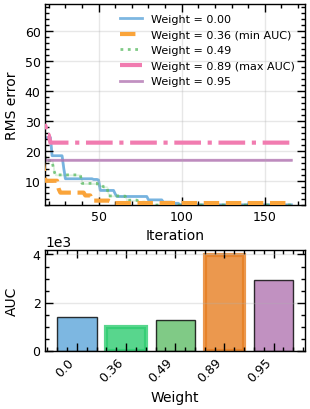

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scienceplots

plt.style.use(["science", "notebook"])


def pad_de_history(
    de_history: np.ndarray, desired_length: int
) -> np.ndarray:
    if len(de_history.shape) == 0 or de_history.size == 1:
        return de_history
    if len(de_history) < desired_length:
        last_val = de_history[-1] if len(de_history) > 0 else 0
        return np.pad(
            de_history,
            (0, desired_length - len(de_history)),
            mode="constant",
            constant_values=last_val,
        )
    return de_history[:desired_length]


def normalize_de_history(df: pd.DataFrame) -> pd.DataFrame:
    final_values = []
    for _, row in df.iterrows():
        de_history = row["de_history_padded"]
        if len(de_history) == 1:
            final_values.append(0)
        else:
            final_values.append(de_history[-1])
    min_final_value = np.min(final_values)
    df["de_history_normalized"] = df["de_history_padded"].apply(
        lambda x: x - min_final_value
    )
    return df


def auc(de_history: np.ndarray) -> float:
    if len(de_history) == 1:
        return np.nan
    return np.trapezoid(de_history, dx=1)


def find_closest_weight(
    target: float, available_weights: list[float]
) -> float | None:
    if not available_weights:
        return None
    return min(available_weights, key=lambda x: abs(x - target))


df_dft = pd.read_parquet(
    "../../data/processed/fitting/anisotropy_weight_scan_dft.parquet"
)
df_free = pd.read_parquet(
    "../../data/processed/fitting/anisotropy_weight_scan.parquet"
)

df_dft = df_dft.loc[:, ~df_dft.columns.str.contains("^Unnamed")]
df_free = df_free.loc[:, ~df_free.columns.str.contains("^Unnamed")]
df_dft = df_dft.loc[:, ~df_dft.columns.str.contains("obj")]
df_free = df_free.loc[:, ~df_free.columns.str.contains("obj")]

all_histories = []
for hist in df_free["de_history"]:
    if len(hist) > 1:
        all_histories.append(hist)

max_length = (
    max(len(hist) for hist in all_histories) if all_histories else 100
)

df_free["de_history_padded"] = df_free["de_history"].apply(
    lambda x: pad_de_history(x, desired_length=max_length)
)

df_free = normalize_de_history(df_free)

df_free["aoc"] = df_free["de_history_padded"].apply(auc)

weights_available = sorted(
    [w for w in df_free["weight"].unique() if 0 <= w <= 1]
)

convergence_data = {}
aoc_data = {}

for weight in weights_available:
    weight_df = df_free[df_free["weight"] == weight]

    if len(weight_df) == 0:
        continue

    histories = []
    for _, row in weight_df.iterrows():
        hist = row["de_history_normalized"]
        if len(hist) > 1:
            histories.append(hist)

    if not histories:
        continue

    histories_array = np.array(histories)
    mean_history = np.mean(histories_array, axis=0)
    std_history = np.std(histories_array, axis=0)

    convergence_data[weight] = {
        "mean": mean_history,
        "std": std_history,
        "points": np.arange(1, len(mean_history) + 1),
    }

    aoc_values = weight_df["aoc"].dropna()
    if len(aoc_values) > 0:
        aoc_data[weight] = {
            "mean": aoc_values.mean(),
            "std": aoc_values.std(),
        }

if not aoc_data:
    raise ValueError("No AUC data found")

min_aoc_weight = min(aoc_data, key=lambda x: aoc_data[x]["mean"])
max_aoc_weight = max(aoc_data, key=lambda x: aoc_data[x]["mean"])

target_weights = [0.0, 0.5, 1.0, min_aoc_weight, max_aoc_weight]
selected_weights = []

for target in target_weights:
    if target in convergence_data and target in aoc_data:
        selected_weights.append(target)
    else:
        closest = find_closest_weight(
            target, list(convergence_data.keys())
        )
        if closest is not None and closest in aoc_data:
            if closest not in selected_weights:
                selected_weights.append(closest)
                print(
                    f"Weight {target:.2f} not found, "
                    f"using closest: {closest:.3f}"
                )

selected_weights = sorted(list(set(selected_weights)))

if len(selected_weights) < 5:
    print(
        f"Warning: Only found {len(selected_weights)} weights. "
        f"Available weights: {weights_available[:10]}"
    )

print(f"Selected weights: {selected_weights}")
print(
    f"Min AUC weight: {min_aoc_weight:.3f}, "
    f"Max AUC weight: {max_aoc_weight:.3f}"
)

fig_width = 3.35
fig_height = 4.5
fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(fig_width, fig_height),
    height_ratios=[2, 1],
    gridspec_kw={"hspace": 0.3},
)

line_styles = ["-", "--", ":", "-.", "-"]
colors = [
    "#5DA5DA",
    "#FAA43A",
    "#60BD68",
    "#F17CB0",
    "#B276B2",
    "#DECF3F",
]

for idx, weight in enumerate(selected_weights):
    if weight not in convergence_data:
        continue

    data = convergence_data[weight]
    style = line_styles[idx % len(line_styles)]
    color = colors[idx % len(colors)]

    is_chosen = abs(weight - 0.5) < 1e-3
    is_min = abs(weight - min_aoc_weight) < 1e-3
    is_max = abs(weight - max_aoc_weight) < 1e-3

    linewidth = 3.0 if (is_chosen or is_min or is_max) else 2.0
    alpha = 1.0 if (is_chosen or is_min or is_max) else 0.8
    zorder = 10 if (is_chosen or is_min or is_max) else 1

    if is_chosen:
        label = f"Weight = {weight:.1f} (chosen)"
    elif is_min:
        label = f"Weight = {weight:.2f} (min AUC)"
    elif is_max:
        label = f"Weight = {weight:.2f} (max AUC)"
    else:
        label = f"Weight = {weight:.2f}"

    ax1.plot(
        data["points"],
        data["mean"],
        linestyle=style,
        color=color,
        linewidth=linewidth,
        label=label,
        alpha=alpha,
        zorder=zorder,
    )

    if not (is_chosen or is_min or is_max):
        ax1.fill_between(
            data["points"],
            data["mean"] - data["std"],
            data["mean"] + data["std"],
            alpha=0.2,
            color=color,
        )

threshold = 0.005
ax1.axhline(
    y=threshold,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    alpha=0.7,
    zorder=0,
)

all_means = []
for weight in selected_weights:
    if weight in convergence_data:
        all_means.extend(convergence_data[weight]["mean"])

if all_means:
    y_min = min(all_means) - 0.01
    y_max = max(all_means) + 0.01
    ax1.set_ylim(y_min, y_max)

ax1.set_xlabel("Iteration", fontsize=10)
ax1.set_ylabel("RMS error", fontsize=10)
ax1.set_xlim(left=18)
ax1.tick_params(axis="both", labelsize=9)
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper right", fontsize=8, framealpha=0.9)

aoc_means = []
aoc_stds = []
aoc_weights = []
aoc_colors = []

for weight in selected_weights:
    if weight in aoc_data:
        aoc_means.append(aoc_data[weight]["mean"])
        aoc_stds.append(aoc_data[weight]["std"])
        aoc_weights.append(weight)
        is_chosen = abs(weight - 0.5) < 1e-3
        is_min = abs(weight - min_aoc_weight) < 1e-3
        is_max = abs(weight - max_aoc_weight) < 1e-3

        if is_chosen:
            aoc_colors.append("#E74C3C")
        elif is_min:
            aoc_colors.append("#2ECC71")
        elif is_max:
            aoc_colors.append("#E67E22")
        else:
            color_idx = selected_weights.index(weight) % len(colors)
            aoc_colors.append(colors[color_idx])

x_pos = np.arange(len(aoc_means))
edgecolors = []
edgewidths = []
for w in aoc_weights:
    is_chosen = abs(w - 0.5) < 1e-3
    is_min = abs(w - min_aoc_weight) < 1e-3
    is_max = abs(w - max_aoc_weight) < 1e-3
    if is_chosen:
        edgecolors.append("#E74C3C")
        edgewidths.append(3)
    elif is_min:
        edgecolors.append("#2ECC71")
        edgewidths.append(3)
    elif is_max:
        edgecolors.append("#E67E22")
        edgewidths.append(3)
    else:
        edgecolors.append("none")
        edgewidths.append(1)

bars = ax2.bar(
    x_pos,
    aoc_means,
    yerr=aoc_stds,
    color=aoc_colors,
    alpha=0.8,
    capsize=5,
    edgecolor=edgecolors,
    linewidth=edgewidths,
    error_kw={"elinewidth": 1.5},
)

ax2.set_ylabel("AUC", fontsize=10)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(
    [
        f"{w:.1f}" if abs(w - round(w)) < 1e-3 else f"{w:.2f}"
        for w in aoc_weights
    ],
    fontsize=9,
    rotation=45,
    ha="right",
)
ax2.set_xlabel("Weight", fontsize=10)
ax2.tick_params(axis="both", labelsize=9)
ax2.grid(True, alpha=0.3, axis="y")
ax2.set_ylim(bottom=0)
ax2.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
ax2.yaxis.get_offset_text().set_fontsize(10)

fig.align_ylabels([ax1, ax2])

plt.tight_layout()
plt.savefig("convergence_aoc_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [26]:
print((df_dft["weight"] - .5).abs().idxmin())

49


In [39]:
print(f"{df_dft["weight"].loc[50]:.2g}")

0.51


Selected weights: [np.float64(0.0), np.float64(0.36), np.float64(0.89)]
Min AUC weight: 0.360000 (truncated: 0.36), Max AUC weight: 0.890000 (truncated: 0.89)


/tmp/ipykernel_3827799/938562697.py:358: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


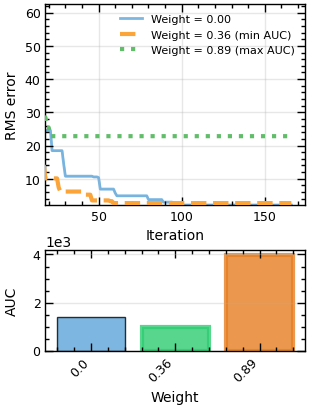

Target 0.50 mapped to 0.490000 (linspace: 0.494949)
Target 0.36 mapped to 0.360000 (linspace: 0.363636)
Target 0.89 mapped to 0.890000 (linspace: 0.888889)
Selected weights: [np.float64(0.0), np.float64(0.36), np.float64(0.49), np.float64(0.89)]
Min AUC weight: 0.360000 (mapped: 0.363636), Max AUC weight: 0.890000 (mapped: 0.888889)


/tmp/ipykernel_3827799/4179043778.py:335: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


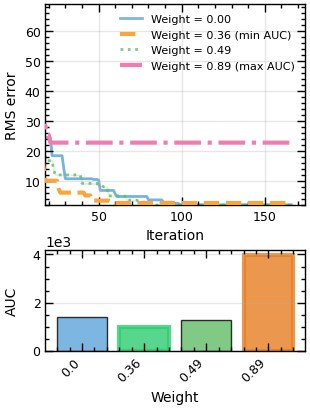

In [50]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scienceplots

plt.style.use(["science", "notebook"])


def pad_de_history(
    de_history: np.ndarray, desired_length: int
) -> np.ndarray:
    if len(de_history) == 1:
        return de_history
    if len(de_history) < desired_length:
        last_val = de_history[-1] if len(de_history) > 0 else 0
        return np.pad(
            de_history,
            (0, desired_length - len(de_history)),
            mode="constant",
            constant_values=last_val,
        )
    return de_history[:desired_length]


def normalize_de_history(df: pd.DataFrame) -> pd.DataFrame:
    final_values = []
    for _, row in df.iterrows():
        de_history = row["de_history_padded"]
        if len(de_history) == 1:
            final_values.append(0)
        else:
            final_values.append(de_history[-1])
    min_final_value = np.min(final_values)
    df["de_history_normalized"] = df["de_history_padded"].apply(
        lambda x: x - min_final_value
    )
    return df


def auc(de_history: np.ndarray) -> float:
    if len(de_history) == 1:
        return np.nan
    return np.trapezoid(de_history, dx=1)

def fix_floating(weight: float) -> float:
    weight_str = str(weight)[:4]
    return float(weight_str)


df_dft = pd.read_parquet(
    "../../data/processed/fitting/anisotropy_weight_scan_dft.parquet"
)
df_free = pd.read_parquet(
    "../../data/processed/fitting/anisotropy_weight_scan.parquet"
)

df_dft = df_dft.loc[:, ~df_dft.columns.str.contains("^Unnamed")]
df_free = df_free.loc[:, ~df_free.columns.str.contains("^Unnamed")]
df_dft = df_dft.loc[:, ~df_dft.columns.str.contains("obj")]
df_free = df_free.loc[:, ~df_free.columns.str.contains("obj")]

df_dft["weight"] = df_dft["weight"].apply(fix_floating)
df_free["weight"] = df_free["weight"].apply(fix_floating)

all_histories = []
for hist in df_free["de_history"]:
    if len(hist) > 1:
        all_histories.append(hist)

max_length = (
    max(len(hist) for hist in all_histories) if all_histories else 100
)

df_free["de_history_padded"] = df_free["de_history"].apply(
    lambda x: pad_de_history(x, desired_length=max_length)
)

df_free = normalize_de_history(df_free)

df_free["aoc"] = df_free["de_history_padded"].apply(auc)

weights_available = sorted(
    [w for w in df_free["weight"].unique() if 0 <= w <= 1]
)

df_free["weight_mapped"] = df_free["weight"].apply(fix_floating)
convergence_data = {}
aoc_data = {}

for weight in weights_available:
    weight_df = df_free[df_free["weight"] == weight]

    if len(weight_df) == 0:
        continue

    histories = []
    for _, row in weight_df.iterrows():
        hist = row["de_history_normalized"]
        if len(hist) > 1:
            histories.append(hist)

    if not histories:
        continue

    histories_array = np.array(histories)
    mean_history = np.mean(histories_array, axis=0)
    std_history = np.std(histories_array, axis=0)

    convergence_data[weight] = {
        "mean": mean_history,
        "std": std_history,
        "points": np.arange(1, len(mean_history) + 1),
    }

    aoc_values = weight_df["aoc"].dropna()
    if len(aoc_values) > 0:
        aoc_data[weight] = {
            "mean": aoc_values.mean(),
            "std": aoc_values.std(),
        }

if not aoc_data:
    raise ValueError("No AUC data found")

min_aoc_weight = min(aoc_data, key=lambda x: aoc_data[x]["mean"])
max_aoc_weight = max(aoc_data, key=lambda x: aoc_data[x]["mean"])

target_weights = [0.0, 0.5, 1.0, min_aoc_weight, max_aoc_weight]
selected_weights = []

for target in target_weights:
    found_weight = find_weight_in_mapping(target, weight_map)
    if found_weight is not None:
        if found_weight in convergence_data and found_weight in aoc_data:
            if found_weight not in selected_weights:
                selected_weights.append(found_weight)
                mapped_value = weight_map[found_weight]
                if abs(target - mapped_value) > 1e-6:
                    print(
                        f"Target {target:.2f} mapped to "
                        f"{found_weight:.6f} (linspace: {mapped_value:.6f})"
                    )
    else:
        print(f"Warning: Could not find weight close to {target:.2f}")

selected_weights = sorted(list(set(selected_weights)))

if len(selected_weights) < 5:
    print(
        f"Warning: Only found {len(selected_weights)} weights. "
        f"Available weights: {weights_available[:10]}"
    )

print(f"Selected weights: {selected_weights}")
print(
    f"Min AUC weight: {min_aoc_weight:.6f} "
    f"(mapped: {weight_map.get(min_aoc_weight, min_aoc_weight):.6f}), "
    f"Max AUC weight: {max_aoc_weight:.6f} "
    f"(mapped: {weight_map.get(max_aoc_weight, max_aoc_weight):.6f})"
)

fig_width = 3.35
fig_height = 4.5
fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(fig_width, fig_height),
    height_ratios=[2, 1],
    gridspec_kw={"hspace": 0.3},
)

line_styles = ["-", "--", ":", "-.", "-"]
colors = [
    "#5DA5DA",
    "#FAA43A",
    "#60BD68",
    "#F17CB0",
    "#B276B2",
    "#DECF3F",
]

for idx, weight in enumerate(selected_weights):
    if weight not in convergence_data:
        continue

    data = convergence_data[weight]
    style = line_styles[idx % len(line_styles)]
    color = colors[idx % len(colors)]

    mapped_weight = weight_map.get(weight, weight)
    is_chosen = abs(mapped_weight - 0.5) < 1e-6
    is_min = abs(weight - min_aoc_weight) < 1e-6
    is_max = abs(weight - max_aoc_weight) < 1e-6

    linewidth = 3.0 if (is_chosen or is_min or is_max) else 2.0
    alpha = 1.0 if (is_chosen or is_min or is_max) else 0.8
    zorder = 10 if (is_chosen or is_min or is_max) else 1

    if is_chosen:
        label = f"Weight = {mapped_weight:.1f} (chosen)"
    elif is_min:
        label = f"Weight = {mapped_weight:.2f} (min AUC)"
    elif is_max:
        label = f"Weight = {mapped_weight:.2f} (max AUC)"
    else:
        label = f"Weight = {mapped_weight:.2f}"

    ax1.plot(
        data["points"],
        data["mean"],
        linestyle=style,
        color=color,
        linewidth=linewidth,
        label=label,
        alpha=alpha,
        zorder=zorder,
    )

    if not (is_chosen or is_min or is_max):
        ax1.fill_between(
            data["points"],
            data["mean"] - data["std"],
            data["mean"] + data["std"],
            alpha=0.2,
            color=color,
        )

threshold = 0.005
ax1.axhline(
    y=threshold,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    alpha=0.7,
    zorder=0,
)

all_means = []
for weight in selected_weights:
    if weight in convergence_data:
        all_means.extend(convergence_data[weight]["mean"])

if all_means:
    y_min = min(all_means) - 0.01
    y_max = max(all_means) + 0.01
    ax1.set_ylim(y_min, y_max)

ax1.set_xlabel("Iteration", fontsize=10)
ax1.set_ylabel("RMS error", fontsize=10)
ax1.set_xlim(left=18)
ax1.tick_params(axis="both", labelsize=9)
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper right", fontsize=8, framealpha=0.9)

aoc_means = []
aoc_stds = []
aoc_weights = []
aoc_colors = []
aoc_mapped_weights = []

for weight in selected_weights:
    if weight in aoc_data:
        aoc_means.append(aoc_data[weight]["mean"])
        aoc_stds.append(aoc_data[weight]["std"])
        aoc_weights.append(weight)
        mapped_weight = weight
        aoc_mapped_weights.append(mapped_weight)

        is_chosen = abs(mapped_weight - 0.5) < 1e-6
        is_min = abs(weight - min_aoc_weight) < 1e-6
        is_max = abs(weight - max_aoc_weight) < 1e-6

        if is_chosen:
            aoc_colors.append("#E74C3C")
        elif is_min:
            aoc_colors.append("#2ECC71")
        elif is_max:
            aoc_colors.append("#E67E22")
        else:
            color_idx = selected_weights.index(weight) % len(colors)
            aoc_colors.append(colors[color_idx])

x_pos = np.arange(len(aoc_means))
edgecolors = []
edgewidths = []
for w, mapped_w in zip(aoc_weights, aoc_mapped_weights):
    is_chosen = abs(mapped_w - 0.5) < 1e-6
    is_min = abs(w - min_aoc_weight) < 1e-6
    is_max = abs(w - max_aoc_weight) < 1e-6
    if is_chosen:
        edgecolors.append("#E74C3C")
        edgewidths.append(3)
    elif is_min:
        edgecolors.append("#2ECC71")
        edgewidths.append(3)
    elif is_max:
        edgecolors.append("#E67E22")
        edgewidths.append(3)
    else:
        edgecolors.append("none")
        edgewidths.append(1)

bars = ax2.bar(
    x_pos,
    aoc_means,
    yerr=aoc_stds,
    color=aoc_colors,
    alpha=0.8,
    capsize=5,
    edgecolor=edgecolors,
    linewidth=edgewidths,
    error_kw={"elinewidth": 1.5},
)

ax2.set_ylabel("AUC", fontsize=10)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(
    [
        f"{w:.1f}" if abs(w - round(w)) < 1e-6 else f"{w:.2f}"
        for w in aoc_mapped_weights
    ],
    fontsize=9,
    rotation=45,
    ha="right",
)
ax2.set_xlabel("Weight", fontsize=10)
ax2.tick_params(axis="both", labelsize=9)
ax2.grid(True, alpha=0.3, axis="y")
ax2.set_ylim(bottom=0)
ax2.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
ax2.yaxis.get_offset_text().set_fontsize(10)

fig.align_ylabels([ax1, ax2])

plt.tight_layout()
plt.savefig("convergence_aoc_plot.png", dpi=300, bbox_inches="tight")
plt.show()

Weight 1.0 not available (NaN), using highest valid weight: 0.980
Selected weights: [np.float64(0.0), np.float64(0.33), np.float64(0.5), np.float64(0.98)]
Min AUC weight: 0.330, Max AUC weight: 0.980


/tmp/ipykernel_721363/3133973605.py:406: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


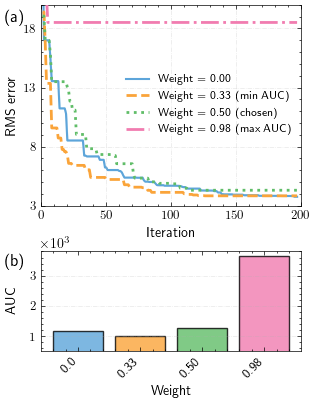

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scienceplots

plt.style.use(["science"])
# don't use math mode for text
plt.rcParams["text.usetex"] = True
# Use A non serif font for all text
plt.rcParams["font.family"] = "sans-serif"


def pad_de_history(
    de_history: np.ndarray, desired_length: int
) -> np.ndarray:
    if len(de_history) == 1:
        return de_history
    if len(de_history) < desired_length:
        last_val = de_history[-1] if len(de_history) > 0 else 0
        return np.pad(
            de_history,
            (0, desired_length - len(de_history)),
            mode="constant",
            constant_values=last_val,
        )
    return de_history[:desired_length]


def normalize_de_history(df: pd.DataFrame) -> pd.DataFrame:
    final_values = []
    for _, row in df.iterrows():
        de_history = row["de_history_padded"]
        if len(de_history) == 1:
            final_values.append(0)
        else:
            final_values.append(de_history[-1])
    min_final_value = np.min(final_values)
    df["de_history_normalized"] = df["de_history_padded"].apply(
        lambda x: x - min_final_value
    )
    return df


def auc(de_history: np.ndarray) -> float:
    if len(de_history) == 1:
        return np.nan
    return np.trapezoid(de_history, dx=1)


def fix_floating(weight: float) -> float:
    weight_str = str(weight)[:4]
    return float(weight_str)


def find_weight_with_tolerance(
    target: float, available_weights: list[float], tolerance: float = 1e-3
) -> float | None:
    for weight in available_weights:
        if abs(weight - target) < tolerance:
            return weight
    return None


def preprocess_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
    df = df.loc[:, ~df.columns.str.contains("obj")]

    # if "converged" in df.columns:
    #     df = df[
    #         ~df["converged"]
    #         .astype(str)
    #         .str.contains("converged", case=False, na=False)
    #     ]

    df["weight"] = df["weight"].apply(fix_floating)

    all_histories = []
    for hist in df["de_history"]:
        if len(hist) > 1:
            all_histories.append(hist)

    max_length = (
        max(len(hist) for hist in all_histories) if all_histories else 100
    )

    df["de_history_padded"] = df["de_history"].apply(
        lambda x: pad_de_history(x, desired_length=max_length)
    )

    df = normalize_de_history(df)

    df["aoc"] = df["de_history_padded"].apply(auc)

    return df


def prepare_convergence_data(
    df: pd.DataFrame,
) -> tuple[dict, dict, float, float]:
    weights_available = sorted(
        [w for w in df["weight"].unique() if 0 <= w <= 1]
    )

    convergence_data = {}
    aoc_data = {}

    for weight in weights_available:
        weight_df = df[df["weight"] == weight]

        if len(weight_df) == 0:
            continue

        histories = []
        for _, row in weight_df.iterrows():
            hist = row["de_history_normalized"]
            if len(hist) > 1:
                histories.append(hist)

        if not histories:
            continue

        histories_array = np.array(histories)
        mean_history = np.mean(histories_array, axis=0)
        std_history = np.std(histories_array, axis=0)

        convergence_data[weight] = {
            "mean": mean_history,
            "std": std_history,
            "points": np.arange(1, len(mean_history) + 1),
        }

        aoc_values = weight_df["aoc"].dropna()
        if len(aoc_values) > 0:
            aoc_data[weight] = {
                "mean": aoc_values.mean(),
                "std": aoc_values.std(),
            }

    if not aoc_data:
        raise ValueError("No AUC data found")

    min_aoc_weight = min(aoc_data, key=lambda x: aoc_data[x]["mean"])
    max_aoc_weight = max(aoc_data, key=lambda x: aoc_data[x]["mean"])

    return convergence_data, aoc_data, min_aoc_weight, max_aoc_weight


def select_weights(
    convergence_data: dict,
    aoc_data: dict,
    min_aoc_weight: float,
    max_aoc_weight: float,
) -> list[float]:
    valid_weights = [
        w
        for w in convergence_data.keys()
        if w in aoc_data
        and not np.isnan(aoc_data[w]["mean"])
    ]

    max_valid_weight = max(valid_weights) if valid_weights else None

    target_weights = [0.0, 0.5, 1.0, min_aoc_weight, max_aoc_weight]
    selected_weights = []

    for target in target_weights:
        found_weight = find_weight_with_tolerance(
            target, valid_weights, tolerance=1e-3
        )

        if target == 1.0 and found_weight is None:
            if max_valid_weight is not None:
                if max_valid_weight not in selected_weights:
                    selected_weights.append(max_valid_weight)
                    print(
                        f"Weight 1.0 not available (NaN), "
                        f"using highest valid weight: {max_valid_weight:.3f}"
                    )
        elif found_weight is not None:
            if found_weight not in selected_weights:
                selected_weights.append(found_weight)
                if abs(target - found_weight) > 1e-6:
                    print(
                        f"Target {target:.2f} found as {found_weight:.3f} "
                        f"(within tolerance)"
                    )
        else:
            print(f"Warning: Could not find weight close to {target:.2f}")

    selected_weights = sorted(set(selected_weights))

    if 0.5 not in selected_weights:
        weight_05_found = find_weight_with_tolerance(
            0.5, valid_weights, tolerance=1e-3
        )
        if weight_05_found is not None:
            print(
                f"DEBUG: Weight 0.5 found as {weight_05_found:.6f}, "
                f"adding to selection"
            )
            selected_weights.append(weight_05_found)
            selected_weights = sorted(set(selected_weights))

    return selected_weights


def plot_convergence_and_aoc(
    convergence_data: dict,
    aoc_data: dict,
    selected_weights: list[float],
    min_aoc_weight: float,
    max_aoc_weight: float,
    output_path: str = "convergence_aoc_plot.png",
) -> plt.Figure:
    fig_width = 3.35
    fig_height = 4.5
    fig, (ax1, ax2) = plt.subplots(
        2,
        1,
        figsize=(fig_width, fig_height),
        height_ratios=[2, 1],
        gridspec_kw={"hspace": 0.3},
    )

    line_styles = ["-", "--", ":", "-.", "-"]
    colors = [
        "#5DA5DA",
        "#FAA43A",
        "#60BD68",
        "#F17CB0",
        "#B276B2",
        "#DECF3F",
    ]

    weight_color_map = {}
    for idx, weight in enumerate(selected_weights):
        weight_color_map[weight] = colors[idx % len(colors)]

    for idx, weight in enumerate(selected_weights):
        if weight not in convergence_data:
            continue

        data = convergence_data[weight]
        style = line_styles[idx % len(line_styles)]
        color = weight_color_map[weight]

        is_chosen = abs(weight - 0.5) < 1e-3
        is_min = abs(weight - min_aoc_weight) < 1e-3
        is_max = abs(weight - max_aoc_weight) < 1e-3

        linewidth = 2 if (is_chosen or is_min or is_max) else 1.5
        alpha = 1.0
        zorder = 10 if (is_chosen or is_min or is_max) else 0

        if is_chosen:
            label = f"Weight = {weight:.2f} (chosen)"
        elif is_min:
            label = f"Weight = {weight:.2f} (min AUC)"
        elif is_max:
            label = f"Weight = {weight:.2f} (max AUC)"
        else:
            label = f"Weight = {weight:.2f}"

        ax1.plot(
            data["points"],
            data["mean"],
            linestyle=style,
            color=color,
            linewidth=linewidth,
            label=label,
            alpha=alpha,
            zorder=zorder,
        )

        if not (is_chosen or is_min or is_max):
            ax1.fill_between(
                data["points"],
                data["mean"] - data["std"],
                data["mean"] + data["std"],
                alpha=0.2,
                color=color,
            )

    threshold = 0.005
    ax1.axhline(
        y=threshold,
        color="gray",
        linestyle="--",
        linewidth=1.5,
        alpha=0.7,
        zorder=0,
    )

    all_means = []
    for weight in selected_weights:
        if weight in convergence_data:
            all_means.extend(convergence_data[weight]["mean"])

    if all_means:
        y_min = min(all_means) - 0.01
        y_max = max(all_means) + 0.01
        y_min_int = int(np.floor(y_min))
        y_max_int = int(np.ceil(y_max))
        ax1.set_yticks(np.arange(y_min_int, y_max_int + 1, 5))

    ax1.set_xlabel("Iteration", fontsize=10)
    ax1.set_ylabel("RMS error", fontsize=10)
    ax1.set_xlim(left=18)
    ax1.tick_params(axis="both", labelsize=9)
    ax1.grid(True, alpha=0.3, linestyle="-.")
    ax1.legend(loc="center right", fontsize=8)

    aoc_means = []
    aoc_stds = []
    aoc_weights = []
    aoc_colors = []

    for weight in selected_weights:
        if weight in aoc_data:
            aoc_means.append(aoc_data[weight]["mean"])
            aoc_stds.append(aoc_data[weight]["std"])
            aoc_weights.append(weight)
            aoc_colors.append(weight_color_map[weight])

    x_pos = np.arange(len(aoc_means))
    edgecolors = []
    edgewidths = []
    for _ in aoc_weights:
        edgecolors.append("none")
        edgewidths.append(1)

    bars = ax2.bar(
        x_pos,
        aoc_means,
        yerr=aoc_stds,
        color=aoc_colors,
        alpha=0.8,
        capsize=5,
        edgecolor=edgecolors,
        linewidth=edgewidths,
        error_kw={"elinewidth": 1.5},
    )

    ax2.set_ylabel("AUC", fontsize=10)
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(
        [
            f"{w:.1f}" if abs(w - round(w)) < 1e-3 else f"{w:.2f}"
            for w in aoc_weights
        ],
        fontsize=9,
        rotation=45,
        ha="right",
    )
    ax2.set_xlabel("Weight", fontsize=10)
    ax2.tick_params(axis="both", labelsize=9)
    ax2.grid(True, alpha=0.3, axis="y", linestyle="-.")
    ax2.set_ylim(bottom=0)
    ax2.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
    ax2.yaxis.get_offset_text().set_fontsize(10)

    fig.align_ylabels([ax1, ax2])
    return fig


df_dft = pd.read_parquet(
    "../../data/processed/fitting/anisotropy_weight_scan_dft.parquet"
)

df_processed = preprocess_dataframe(df_dft)

convergence_data, aoc_data, min_aoc_weight, max_aoc_weight = (
    prepare_convergence_data(df_processed)
)

selected_weights = select_weights(
    convergence_data, aoc_data, min_aoc_weight, max_aoc_weight
)

print(f"Selected weights: {selected_weights}")
print(
    f"Min AUC weight: {min_aoc_weight:.3f}, "
    f"Max AUC weight: {max_aoc_weight:.3f}"
)

fig = plot_convergence_and_aoc(
    convergence_data,
    aoc_data,
    selected_weights,
    min_aoc_weight,
    max_aoc_weight,
)
ax1, ax2 = fig.get_axes()
ax1.set_ylim(3, 20)
ax1.set_xlim(0, 200)
ax2.set_ylim(.5e3, None)
ax1.text(
    -0.14, 0.98, "(a)", transform=ax1.transAxes,
    fontsize=12, fontweight="bold", va="top", ha="left"
)

ax2.text(
    -0.14, 0.98, "(b)", transform=ax2.transAxes,
    fontsize=12, fontweight="bold", va="top", ha="left"
)
fig.tight_layout()
fig.savefig("convergence_aoc_plot.png", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

In [10]:
selected_weights

[np.float64(0.0), np.float64(0.33), np.float64(0.5), np.float64(0.98)]